In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784",as_frame=False)

In [ ]:
X,y = mnist.data,mnist.target

In [ ]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

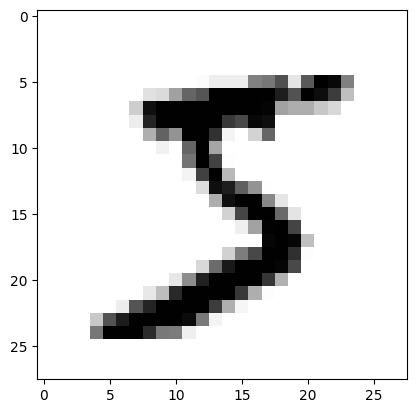

In [ ]:
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image=image_data.reshape(28,28)
    plt.imshow(image,cmap="binary")

some_digit=X[0]
plot_digit(some_digit)
plt.show()

In [ ]:
X_train,X_test,y_train,y_test = X[:60000],X[60000:],y[:60000],y[60000:]

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier





In [ ]:
from sklearn.model_selection import GridSearchCV

knn_clf = GridSearchCV(KNeighborsClassifier(),{
    "n_neighbors":[1,2,3,4,5,6,7,8]

},cv=3,return_train_score=False)
knn_clf.fit(X_train,y_train)


GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8]})

In [ ]:
knn_clf.cv_results_

{'mean_fit_time': array([0.19177119, 0.18980352, 0.19015137, 0.1840299 , 0.21167604,
        0.2267797 , 0.18253771, 0.18536949]),
 'std_fit_time': array([0.00876033, 0.00689945, 0.00665283, 0.00033381, 0.02854878,
        0.02900419, 0.00179559, 0.00260025]),
 'mean_score_time': array([55.71347316, 54.40432604, 54.19160787, 53.06764007, 53.47969071,
        53.29087869, 52.98521026, 53.1417671 ]),
 'std_score_time': array([1.28227888, 0.35026648, 0.54890621, 0.03981394, 0.66780496,
        0.15793494, 0.59636512, 0.20241846]),
 'param_n_neighbors': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=999999),
 'params': [{'n_neighbors': 1},
  {'n_neighbors': 2},
  {'n_neighbors': 3},
  {'n_neighbors': 4},
  {'n_neighbors': 5},
  {'n_neighbors': 6},
  {'n_neighbors': 7},
  {'n_neighbors': 8}],
 'split0_test_score': array([0.96875, 0.95965, 0.969  , 0.96625, 0.9676 , 0.9654 , 0.9649 ,
        0.96365]

In [ ]:
from pandas import DataFrame
df = DataFrame(knn_clf.cv_results_)

In [ ]:
df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.191771,0.008760,55.713473,1.282279,1,{'n_neighbors': 1},0.96875,0.96685,0.96705,0.967550,0.000852,2
1,0.189804,0.006899,54.404326,0.350266,2,{'n_neighbors': 2},0.95965,0.96040,0.96160,0.960550,0.000803,8
2,0.190151,0.006653,54.191608,0.548906,3,{'n_neighbors': 3},0.96900,0.96805,0.96750,0.968183,0.000620,1
3,0.184030,0.000334,53.067640,0.039814,4,{'n_neighbors': 4},0.96625,0.96640,0.96725,0.966633,0.000440,4
4,0.211676,0.028549,53.479691,0.667805,5,{'n_neighbors': 5},0.96760,0.96710,0.96755,0.967417,0.000225,3
5,0.226780,0.029004,53.290879,0.157935,6,{'n_neighbors': 6},0.96540,0.96520,0.96590,0.965500,0.000294,5
6,0.182538,0.001796,52.985210,0.596365,7,{'n_neighbors': 7},0.96490,0.96460,0.96610,0.965200,0.000648,6
7,0.185369,0.002600,53.141767,0.202418,8,{'n_neighbors': 8},0.96365,0.96370,0.96570,0.964350,0.000955,7


In [ ]:
df[["param_n_neighbors","mean_test_score"]].sort_values(by='mean_test_score',ascending=False) # best k is 3

,param_n_neighbors,mean_test_score
2,3,0.968183
0,1,0.967550
4,5,0.967417
3,4,0.966633
5,6,0.965500
6,7,0.965200
7,8,0.964350
1,2,0.960550


In [ ]:
knn_clf = KNeighborsClassifier(n_neighbors=3)
knn_clf.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(knn_clf,X_train,y_train,cv=3,scoring="accuracy")

In [ ]:
accuracies

array([0.969  , 0.96805, 0.9675 ])

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_predictions = cross_val_predict(knn_clf,X_train,y_train,cv=3)

In [20]:
from sklearn.metrics import f1_score
f1_score(y_train,y_train_predictions,average="macro")

0.9679621545505714